<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner code, texte et graphiques.

Cet outil est formidable pour plusieurs raisons:

+ Il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'une instruction, de la corriger si nécessaire.
+ Il permet aussi de rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ Il est possible d'ajouter des graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandé.

Et gardez à l'esprit qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [82]:
#Importation de la librairie Pandas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import textwrap

In [83]:
#Importation de la librairie plotly express
import plotly.express as px

In [84]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir dans Google les mots clés "display all columns dataframe Pandas" par exemple.
#Dans les résultats de la recherche, privilégier les solutions provenant de Stack Overflow ou Medium

pd.set_option('display.max_columns', None)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [85]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [86]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [87]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    str    
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 38.8 KB


In [88]:
#Afficher les 5 premières lignes de la table
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [89]:
#Vérifier si il y a des lignes en doublon dans la colonne product_id
df_erp.loc[df_erp['product_id'].duplicated(keep=False), :]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [90]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
col_stock = df_erp['stock_status'].unique()
print(f"La colonne stock_status contient ces valeurs : {', '.join(col_stock)}.")
print("C'est valeurs sont liées a la colonne stock_quantity.")

La colonne stock_status contient ces valeurs : instock, outofstock.
C'est valeurs sont liées a la colonne stock_quantity.


In [91]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = np.where(df_erp['stock_quantity'] <= 0, 'outofstock', 'instock')

In [92]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]

#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [93]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0
#Nous devrions obtenir la somme de 825 qui correspond au nombre de lignes dans ce dataset
(df_erp["stock_status"] == df_erp["stock_status_2"]).value_counts()

True     823
False      2
Name: count, dtype: int64

In [94]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
mask = df_erp['stock_status'] != df_erp['stock_status_2']
df_erp_diff = df_erp[mask]
df_erp_diff.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [95]:
#Corriger la ou les données incohérentes
df_erp['stock_status'] = df_erp['stock_status_2']
#Vérification en utilisant le même code que plus haut pour afficher les problèmes
df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [96]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatifs ou nuls?
#Afficher le ou les prix non renseignés dans la colonne "price"
prix_v_nuls = df_erp.query("price.isnull()")
print("Nombres d'articles avec un prix non renseigné: {}".format(len(prix_v_nuls))) #Saisir l'instruction manquante dans la fonction format
#Afficher le prix minimum de la colonne "price"
prix_v_min = df_erp['price'].min()
print(f"Le prix le plus bas est {prix_v_min}€")
#Afficher le prix maximum de la colonne "price"
prix_v_max = df_erp['price'].max()
print(f"Le prix le plus haut est {prix_v_max}€")
#Afficher les prix inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
prix_v_neg = df_erp.query("price < 0")
print(f"Liste des prix négatifs :")
display(prix_v_neg)
print("Une analyse des prix négatifs a été effectuée.\n" \
      "Si le croisement avec la table produits confirme une erreur de saisie, une correction sera proposée.\n" \
      "Dans tous les cas, ces anomalies seront remontées au métier (donneur d'ordre) pour validation.")

Nombres d'articles avec un prix non renseigné: 0
Le prix le plus bas est -20.0€
Le prix le plus haut est 225.0€
Liste des prix négatifs :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
151,4233,0,-20.0,0,outofstock,10.33,outofstock
469,5017,0,-8.0,0,outofstock,4.34,outofstock
739,6594,0,-9.1,19,instock,4.61,instock


Une analyse des prix négatifs a été effectuée.
Si le croisement avec la table produits confirme une erreur de saisie, une correction sera proposée.
Dans tous les cas, ces anomalies seront remontées au métier (donneur d'ordre) pour validation.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [97]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
stock_min = df_erp['stock_quantity'].min()
print(f"Le stock le plus bas est de {stock_min} unitées.")
#Afficher la quantité maximum de la colonne "stock_quantity"
stock_max = df_erp['stock_quantity'].max()
print(f"Le stock le plus haut est de {stock_max} unitées.")
#Afficher les stocks inférieurs à 0 (qu'est-ce qu'il faut en faire ?)
stock_neg = df_erp.query("stock_quantity < 0")
print(f"Liste des stocks négatifs :")
display(stock_neg)
print("Analyse des stocks négatifs effectuée.\n"
      "Traitement appliqué : Passage en 'outofstock' (erreur d'inventaire).\n"
      "Note : Anomalies à remonter au métier pour validation.")

Le stock le plus bas est de -10 unitées.
Le stock le plus haut est de 145 unitées.
Liste des stocks négatifs :


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


Analyse des stocks négatifs effectuée.
Traitement appliqué : Passage en 'outofstock' (erreur d'inventaire).
Note : Anomalies à remonter au métier pour validation.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [98]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient. Que signifient-elles?
df_erp['onsale_web'].value_counts(dropna=False)

onsale_web
1    716
0    109
Name: count, dtype: int64

In [99]:
print("1 : le produit est vendu sur le site.\n" \
      "2 : le produit n'est pas vendu sur le site.")

1 : le produit est vendu sur le site.
2 : le produit n'est pas vendu sur le site.


In [100]:
#Quelles sont les colonnes à conserver selon vous?
print("Toutes les colonnes sauf la colonne stock_status_2 qui n'est plus utile.")

Toutes les colonnes sauf la colonne stock_status_2 qui n'est plus utile.


In [101]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp.drop(columns='stock_status_2', inplace=True)

In [102]:
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [103]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
prix_ha_nuls = df_erp.query("purchase_price.isnull()")
print(f"Nombres d'articles avec un prix non renseigné: {len(prix_ha_nuls)}")
#Afficher le prix minimum de la colonne "purchase_price"
prix_ha_min = df_erp['purchase_price'].min()
print(f"Le prix le plus bas est {prix_ha_min}€")
#Afficher le prix maximum de la colonne "purchase_price"
prix_ha_max = df_erp['purchase_price'].max()
print(f"Le prix le plus bas est {prix_ha_max}€")


Nombres d'articles avec un prix non renseigné: 0
Le prix le plus bas est 2.74€
Le prix le plus bas est 137.81€


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [104]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_web.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_web.shape[1]))

Le tableau comporte 1513 observation(s) ou article(s)
Le tableau comporte 29 colonne(s)


In [105]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    str           
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[us]
 10  post_date_gmt          1430 non-null   datetime64[us]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   str           
 13  post_title    

In [106]:
df_web.head()

,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
0,14950,0,0,0,0.0,122.0,NaN,NaN,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,NaN,Vin,François Baur Pinot Noir Schlittweg 2017,NaN,publish,closed,closed,NaN,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1,1366,0,0,0,0.0,116.0,NaN,NaN,2.0,2018-02-13 13:45:31,2018-02-13 12:45:31,NaN,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,NaN,publish,closed,closed,NaN,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
2,14561,0,0,0,0.0,111.0,NaN,NaN,2.0,2018-09-01 15:34:55,2018-09-01 13:34:55,NaN,Vin,Argentine Mendoza Alamos Torrontes 2017,NaN,publish,closed,closed,NaN,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
3,16148,0,0,0,0.0,36.0,taxable,NaN,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,NaN,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,"<div>\n\nUn rosé minéral, fruité et d’une gran...",publish,closed,closed,NaN,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
4,16148,0,0,0,0.0,36.0,NaN,NaN,2.0,2018-05-03 13:20:05,2018-05-03 11:20:05,NaN,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,NaN,publish,closed,closed,NaN,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,2020-08-27 09:30:15,2020-08-27 07:30:15,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0


In [107]:
#Selon vous, quelles sont les colonnes à conserver ?
print("Cet affichage nous permet de voir le details des colonnes :")
stats = pd.DataFrame({
    'nulls': df_web.isnull().sum(),
    'unique_values': df_web.nunique(),
    'type': df_web.dtypes
})
display(stats)

Cet affichage nous permet de voir le details des colonnes :


,nulls,unique_values,type
sku,85,714,object
virtual,0,1,int64
downloadable,0,1,int64
rating_count,0,1,int64
average_rating,83,1,float64
total_sales,83,29,float64
tax_status,797,1,str
tax_class,1513,0,float64
post_author,83,2,float64
post_date,83,716,datetime64[us]


In [108]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
print("On ne garde pas les colonnes sans information (100% null).\n")
df_web.dropna(axis='columns', how='all', inplace=True)

print("On ne garde pas les colonnes qui ne contienne qu'une information.")
cols_inutiles = []
for col in df_web.columns:
    if df_web[col].nunique() <= 1:
        cols_inutiles.append(col)
        
print(f"Colonnes avec 0 ou 1 seule valeur : {cols_inutiles}\n")
# on teste les colonnes avec : df_web['total_sales'].value_counts(dropna=False)
df_web = df_web.drop(columns=cols_inutiles, errors='ignore')

print("Il ya deux informations de dates : une au format CET et une au format GMT : inutile de concerver les deux.\n")
df_web = df_web.drop(columns=['post_date_gmt', 'post_modified_gmt'], errors='ignore')


liste = ['post_author', 'post_excerpt', 'post_name', 'post_modified', 'guid']
print(f"Les informations suivantes :\n{', '.join(liste)}, ne sont pas pertinente pour l'analyse future.\n" \
      "A confirmer avec la partie metier pour la future DB.\n")
df_web = df_web.drop(columns=liste, errors='ignore')

print(f"Nombre de colonnes restantes : {df_web.shape[1]}")

stats = pd.DataFrame({
    'nulls': df_web.isnull().sum(),
    'unique_values': df_web.nunique(),
    'type': df_web.dtypes
})
display(stats)

On ne garde pas les colonnes sans information (100% null).

On ne garde pas les colonnes qui ne contienne qu'une information.
Colonnes avec 0 ou 1 seule valeur : ['virtual', 'downloadable', 'rating_count', 'average_rating', 'tax_status', 'post_status', 'comment_status', 'ping_status', 'post_parent', 'menu_order', 'post_mime_type', 'comment_count']

Il ya deux informations de dates : une au format CET et une au format GMT : inutile de concerver les deux.

Les informations suivantes :
post_author, post_excerpt, post_name, post_modified, guid, ne sont pas pertinente pour l'analyse future.
A confirmer avec la partie metier pour la future DB.

Nombre de colonnes restantes : 6


,nulls,unique_values,type
sku,85,714,object
total_sales,83,29,float64
post_date,83,716,datetime64[us]
product_type,84,7,str
post_title,83,713,str
post_type,83,2,str


In [109]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
nb_nan_sku = df_web['sku'].isna().sum()
nb_doublons_sku = df_web.duplicated(subset=['sku']).sum()
print(f"La colonnes sku contient {nb_doublons_sku - nb_nan_sku + 1} doublons, et {nb_nan_sku} valeurs nulles.")

La colonnes sku contient 714 doublons, et 85 valeurs nulles.


In [110]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les
# df_web['sku'].unique() semble donner des résultats étranges mais une verif de correspondance avec la table liaison montre qu'il n'y a pas de problème.
orphelins = df_web[~df_web['sku'].isin(df_liaison['id_web'])]
print(f"Produits Web sans correspondance dans Liaison : {len(orphelins)}")

Produits Web sans correspondance dans Liaison : 0


In [111]:
#Identifier les lignes sans code article
df_web_null = df_web.loc[df_web['sku'].isna()]
df_web_null.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 1428 to 1512
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   sku           0 non-null      object        
 1   total_sales   2 non-null      float64       
 2   post_date     2 non-null      datetime64[us]
 3   product_type  2 non-null      str           
 4   post_title    2 non-null      str           
 5   post_type     2 non-null      str           
dtypes: datetime64[us](1), float64(1), object(1), str(3)
memory usage: 4.1+ KB


In [112]:
#Pour les codes articles identifiés, réaliser une analyse et définir l'action à entreprendre
print("Les lignes concernées ne contenant que des NaN on peux les supprimer sans risques.")
df_web.dropna(subset=['sku'], inplace=True)

Les lignes concernées ne contenant que des NaN on peux les supprimer sans risques.


In [113]:
#La clé pour chaque ligne est-elle unique? autrement dit, y a-t-il des doublons?
nb_doublons_sku = df_web.duplicated(subset=['sku']).sum()
print(f"Il y a {nb_doublons_sku} doublons de clé.")

Il y a 714 doublons de clé.


In [114]:
# On crée un DF qui contient toutes les lignes dont le SKU est déjà apparu
df_web_doublons = df_web[df_web.duplicated(subset=['sku'], keep=False)]

# On trie par SKU pour bien voir les doublons côte à côte
df_web_doublons['sku'] = df_web_doublons['sku'].astype(str)
df_web_doublons = df_web_doublons.sort_values(by='sku')

df_web_doublons.head(10)

,sku,total_sales,post_date,product_type,post_title,post_type
442,10014,10.0,2019-04-04 15:45:23,Gin,Darnley's London Dry Gin Original,product
477,10014,10.0,2019-04-04 15:45:23,Gin,Darnley's London Dry Gin Original,attachment
1189,10459,4.0,2018-04-13 15:58:19,Vin,Alphonse Mellot Sancerre Rouge Génération XIX ...,product
1198,10459,4.0,2018-04-13 15:58:19,Vin,Alphonse Mellot Sancerre Rouge Génération XIX ...,attachment
1024,10775,6.0,2018-04-17 21:28:52,Vin,Albert Mann Pinot Gris Vendanges Tardives Alte...,attachment
981,10775,6.0,2018-04-17 21:28:52,Vin,Albert Mann Pinot Gris Vendanges Tardives Alte...,product
858,10814,7.0,2018-04-17 10:12:40,Vin,Thierry Germain Saumur-Champigny Outre Terre 2013,product
831,10814,7.0,2018-04-17 10:12:40,Vin,Thierry Germain Saumur-Champigny Outre Terre 2013,attachment
1168,11049,4.0,2018-04-13 16:07:49,Vin,Alphonse Mellot Sancerre Rouge En Grands Champ...,product
1222,11049,4.0,2018-04-13 16:07:49,Vin,Alphonse Mellot Sancerre Rouge En Grands Champ...,attachment


In [115]:
#On remarque que chaque ref est repétée 2 (product, attachement), on peux donc supprimer attachement sans risque
df_web = df_web.loc[df_web['post_type'] == 'product', :]

#On peux aussi supprimer la colonne post_type qui n'a plus d'utilité
df_web = df_web.drop(columns='post_type', errors='ignore')

#On change le nom de la colonne sku pour les futurs join
df_web = df_web.rename(columns={'sku' : 'id_web'})

#reset des index pour faire propre
df_web.reset_index(drop=True, inplace=True)

In [116]:
#df_web final
df_web.head()

,id_web,total_sales,post_date,product_type,post_title
0,16148,36.0,2018-05-03 13:20:05,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...
1,15415,27.0,2018-02-15 14:33:42,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...
2,14864,24.0,2018-02-27 13:33:54,Vin,I Fabbri Chianti Classico Lamole 2017
3,16525,22.0,2018-04-17 09:28:58,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017
4,14950,22.0,2018-04-18 11:53:51,Vin,François Baur Pinot Noir Schlittweg 2017


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [117]:
#Dimension du dataset
#Nombre d'observations
print("Le tableau comporte {} observation(s) ou article(s)".format(df_liaison.shape[0]))
#Nombre de caractéristiques
print("Le tableau comporte {} colonne(s)".format(df_liaison.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 2 colonne(s)


In [118]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [119]:
#Les valeurs de la colonne "product_id" sont-elles toutes uniques?
dup_productid = df_liaison.duplicated(subset=['product_id']).sum()
print(f"Nombres d'id produits en double : {dup_productid}")

Nombres d'id produits en double : 0


In [120]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
dup_webid = df_liaison.duplicated(subset=['id_web']).sum()
print(f"Nombres d'id web en double: {dup_webid}")

Nombres d'id web en double: 90


In [121]:
df_liaison.duplicated(subset=['id_web'])

0      False
1      False
2      False
3      False
4      False
       ...  
820     True
821     True
822    False
823    False
824    False
Length: 825, dtype: bool

In [122]:
#Avons-nous des articles sans correspondance?
df_liaison.loc[df_liaison['id_web'].isna() | df_liaison['product_id'].isna()]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [123]:
#Fusion des fichiers df_erp et df_liaison
df_merge = df_erp.merge(df_liaison, on='product_id', how='left')

In [124]:
#Y a t-il des lignes ne "matchant" pas entre les 2 fichiers?
print(f"Lignes avant : {len(df_erp)}")
print(f"Lignes après : {len(df_merge)}")

Lignes avant : 825
Lignes après : 825


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [125]:
#Fusionner les datasets df_merge et df_web
df_merge = df_merge.merge(df_web, on='id_web', how='inner')

In [126]:
#Avons-nous des lignes sans correspondance?
print(f"Lignes avant : {len(df_web)}")
print(f"Lignes après : {len(df_merge)}")

Lignes avant : 714
Lignes après : 714


In [127]:
df_merge.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title
0,3847,1,24.2,16,instock,12.88,15298,6.0,2018-02-08 12:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018
1,3849,1,34.3,10,instock,17.54,15296,9.0,2018-02-08 13:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017
2,3850,1,20.8,0,outofstock,10.64,15300,0.0,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...
3,4032,1,14.1,26,instock,6.92,19814,12.0,2018-02-09 14:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...
4,4039,1,46.0,3,instock,23.77,19815,3.0,2018-02-12 09:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017


In [128]:
#On peux donc revenir sur nos prix negatif afin d'avoir toutes les informations
df_merge.query("price < 0")
#Ils ne sont pas vendu sur le site.

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title


In [129]:
df_merge.query("onsale_web == 0")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title
119,4200,0,5.8,33,instock,3.12,16295,14.0,2018-02-15 14:05:06,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...


In [130]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      714 non-null    int64         
 1   onsale_web      714 non-null    int64         
 2   price           714 non-null    float64       
 3   stock_quantity  714 non-null    int64         
 4   stock_status    714 non-null    str           
 5   purchase_price  714 non-null    float64       
 6   id_web          714 non-null    object        
 7   total_sales     714 non-null    float64       
 8   post_date       714 non-null    datetime64[us]
 9   product_type    713 non-null    str           
 10  post_title      714 non-null    str           
dtypes: datetime64[us](1), float64(3), int64(3), object(1), str(3)
memory usage: 61.5+ KB


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

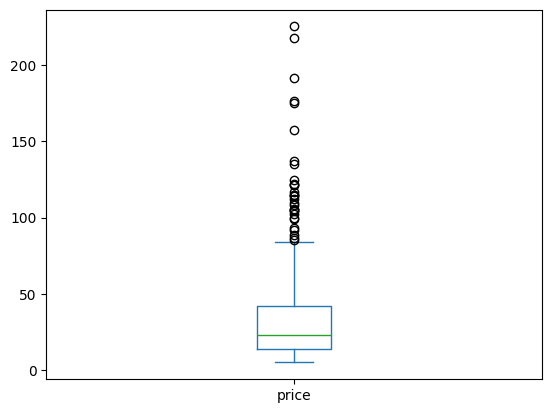

In [ ]:
#Création d'une boîte à moustache de la répartition des prix grâce à Pandas
df_merge['price'].plot(kind='box')

In [132]:
#Autre méthode avec plotly express
px.box(df_merge, 
       x="price", 
       title="Répartition des prix des produits", 
       points='suspectedoutliers',
       hover_name="post_title",
       labels={'price': 'Prix (€)'},
       color_discrete_sequence=["#004D40"]
       )

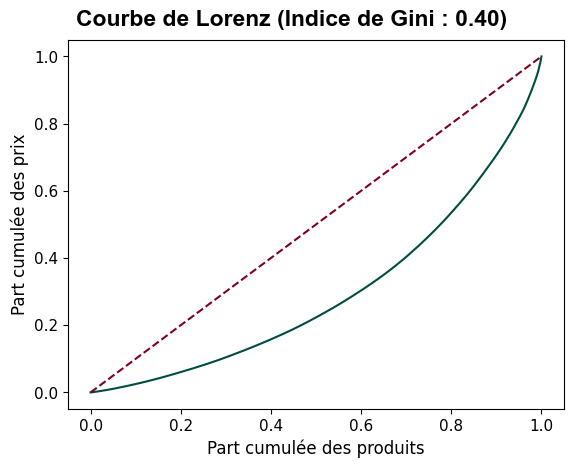

In [133]:
# Lorenz
prix = df_merge.query("price > 0")
prix_sorted = np.sort(prix.price)

lorenz = np.cumsum(prix_sorted) / prix_sorted.sum()
lorenz = np.insert(lorenz, 0, 0)

xaxis = np.linspace(0, 1, len(lorenz))
plt.plot(xaxis, lorenz, drawstyle='default', color='#004D40')
plt.plot([0, 1], [0, 1], color='#800020', linestyle='--')
plt.xlabel("Part cumulée des produits", fontsize=12)
plt.ylabel("Part cumulée des prix", fontsize=12)

# Gini
auc = np.trapezoid(lorenz, xaxis)
gini = 1 - 2 * auc

plt.title(f"Courbe de Lorenz (Indice de Gini : {gini:.2f})", fontname='Arial' , fontweight='bold', pad=10, fontsize=16.5, x=0.45, ha='center')
plt.tick_params(axis='x', labelsize=11)
plt.tick_params(axis='y', labelsize=11)

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [134]:
#Calculer la moyenne du prix
moy_prix = df_merge['price'].mean()
print(f"Prix moyen : {moy_prix:.2f}€")
#Calculer l'écart-type du prix
std_prix = df_merge['price'].std()
print(f"Ecart type : {std_prix:.2f}€")
#std/mean
ratio_std_mean = std_prix / moy_prix
print(f"L'écart type par rapport à la moyenne : {ratio_std_mean:.2f}")
#Calculer le Z-score
df_merge['price_zscore'] = (df_merge['price'] - moy_prix) / std_prix

Prix moyen : 32.33€
Ecart type : 27.60€
L'écart type par rapport à la moyenne : 0.85


In [135]:
#Quel est le seuil prix dont le z-score est supérieur à 3?
seuil_prix = moy_prix + (3 * std_prix)
print(f"Le seuil de prix pour un Z-score > 3 est de : {seuil_prix:.2f}€")

Le seuil de prix pour un Z-score > 3 est de : 115.12€


In [136]:
#Qui ? Z-score > 3 = outlier sévère
z_outliers = df_merge.query("price_zscore > 3")
print(f"Nombre d'ouliers : {len(z_outliers)}")

Nombre d'ouliers : 13


In [137]:
df_merge.query("price_zscore > 3")

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title,price_zscore
199,4352,1,225.0,0,outofstock,137.81,15940,11.0,2018-03-02 10:30:04,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,6.981591
218,4402,1,176.0,11,instock,78.25,3510,3.0,2018-03-22 11:21:05,Cognac,Cognac Frapin VIP XO,5.205993
221,4406,1,157.0,12,instock,69.08,7819,4.0,2018-03-22 11:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.517496
381,4904,1,137.0,9,instock,67.95,14220,3.0,2018-05-15 10:23:41,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,3.792762
426,5001,1,217.5,18,instock,116.87,14581,2.0,2018-07-17 09:45:39,Vin,David Duband Charmes-Chambertin Grand Cru 2014,6.709816
511,5612,1,124.8,19,instock,66.41,14915,1.0,2019-01-15 15:30:49,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,3.350674
553,5767,1,175.0,12,instock,90.42,15185,4.0,2019-03-13 14:43:22,Vin,Camille Giroud Clos de Vougeot 2016,5.169756
587,5892,1,191.3,98,instock,116.06,14983,6.0,2019-03-28 10:21:36,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,5.760415
603,5917,1,122.0,12,instock,54.24,14775,3.0,2019-04-04 16:49:37,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,3.249211
642,6126,1,135.0,138,instock,80.33,14923,5.0,2019-06-28 17:22:27,Champagne,Champagne Gosset Célébris Vintage 2007,3.720288


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [138]:
#Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion
df_merge['price'].describe()

count    714.000000
mean      32.333683
std       27.596332
min        5.200000
25%       14.062500
50%       23.450000
75%       42.075000
max      225.000000
Name: price, dtype: float64

In [139]:
#Définir un seuil pour les articles "outliers" en prix
Q1 = df_merge['price'].quantile(0.25)
Q3 = df_merge['price'].quantile(0.75)

IQR = Q3 - Q1
seuil_bas = Q1 - 1.5 * IQR
seuil_haut = Q3 + 1.5 * IQR

print(f"Seuil de prix bas : {seuil_bas:.2f}€")
print(f"Seuil de prix haut : {seuil_haut:.2f}€")

Seuil de prix bas : -27.96€
Seuil de prix haut : 84.09€


In [140]:
#Définir le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
outliers = df_merge.query("price > @seuil_haut")
print(f"Il y a {len(outliers)} articles qui ont un prix qui sort de nos standard.")
moy_outliers = len(outliers) / len(df_merge) * 100
print(f"Cela représente {moy_outliers:.1f}% de notre catalogue.")

Il y a 31 articles qui ont un prix qui sort de nos standard.
Cela représente 4.3% de notre catalogue.


In [141]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
outliers_check = (
    df_merge
    .query("price > @seuil_haut")
    .loc[:, ['price', 'purchase_price', 'total_sales', 'product_type', 'post_title']]
    .sort_values('price', ascending=False)
    .head())

display(outliers_check)

,price,purchase_price,total_sales,product_type,post_title
199,225.0,137.81,11.0,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008
426,217.5,116.87,2.0,Vin,David Duband Charmes-Chambertin Grand Cru 2014
587,191.3,116.06,6.0,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...
218,176.0,78.25,3.0,Cognac,Cognac Frapin VIP XO
553,175.0,90.42,4.0,Vin,Camille Giroud Clos de Vougeot 2016


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [142]:
##############################
# Calculer le CA du site web #
##############################

#Créer une colonne calculant le CA par article
df_merge['ca'] = df_merge['total_sales'] * df_merge['price']
#Calculer la somme de la colonne "ca_par_article"
#Ce résultat correspond au chiffre d'affaire du site web
ca_global = df_merge['ca'].sum()
print(f"Le CA du site pour octobre est de {ca_global:,.0f}€".replace(',', ' '))

Le CA du site pour octobre est de 143 680€


In [143]:
###############################
# Palmarès des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_merge
prix_sorted = df_merge.sort_values('ca', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
prix_sorted.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en CA
t20_prix = prix_sorted.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
t20_prix['display_name'] = t20_prix['post_title'].apply(lambda x: '<br>'.join(textwrap.wrap(x, width=45)))

fig = px.bar(
    data_frame=t20_prix.sort_values('ca', ascending=True),
    y='display_name',
    x='ca',
    orientation='h',  
    labels={
        'ca': 'Chiffre d\'affaire (€)', 
        'display_name': '', 
        'product_type' : 'Catégorie', 
        'total_sales': 'Nombre d\'articles vendus',
        'price': 'Prix unitaire'},
    color='product_type',
    color_discrete_sequence=['#807700', '#800020', '#004D40'], 
    height=1100,
    width=900,
    category_orders={"display_name": t20_prix['display_name'].tolist()},
    hover_data={
    'ca': False,               # Masque le CA
    'total_sales': ':.0f',     # Affiche le nombre de ventes
    'display_name': False,     # Masque le titre s'il est déjà sur l'axe Y
    'product_type': False,     # Masque la catégorie
    'price': ':.2f'})

fig.update_layout(
    title={
        'text': "<b>Meilleurs contributeurs au CA</b>",
        'y': 0.975,      # Position verticale (0 à 1)
        'x': 0.5,       # Position horizontale (0.5 pour centrer)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}})

fig.update_traces(texttemplate='%{x:.0f} €')

fig.show()

In [144]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
prix_sorted['part_ca'] = prix_sorted['ca'] / ca_global * 100
#Créer une colonne réalisant la somme cumulative de la colonne précédemment créée
prix_sorted['cumul_ca'] = prix_sorted['part_ca'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
ca_80 = len(prix_sorted[prix_sorted['cumul_ca'] <= 80])
print(f"80% du CA est réalisé avec {ca_80} articles.")
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
ratio_ca80 = ca_80 / len(df_merge) * 100
print(f"Cela représente {ratio_ca80:.0f}% de la base articles.")

80% du CA est réalisé avec 434 articles.
Cela représente 61% de la base articles.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en quantité</h3>
</div>

In [145]:
#####################################
# Palmarès des articles en quantité #
#####################################

#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_merge
ventes_sorted = df_merge.sort_values('total_sales', ascending=False)
#Réinitialiser l'index du dataset par un reset_index
ventes_sorted.reset_index(drop=True, inplace=True)
#Afficher les 20 premiers articles en quantité
t20_ventes = ventes_sorted.head(20)
#Graphique en barre des 20 premiers articles avec plotly express
t20_ventes['display_name'] = t20_ventes['post_title'].apply(lambda x: '<br>'.join(textwrap.wrap(x, width=45)))

fig = px.bar(
    data_frame=t20_ventes.sort_values('total_sales', ascending=True),
    y='display_name',
    x='total_sales',
    orientation='h',  
    labels={
        'total_sales': 'Nombre d\'articles vendus', 
        'display_name': '', 
        'product_type' : 'Catégorie', 
        'ca': 'Chiffre d\'affaire',
        'price': 'Prix unitaire'},
    color='product_type',
    color_discrete_sequence=['#800020'], 
    height=1100,
    width=900,
    hover_data={
    'ca': ':.2f',
    'total_sales': ':.0f',     # Affiche le nombre de ventes
    'display_name': False,     # Masque le titre s'il est déjà sur l'axe Y
    'product_type': False,     # Masque la catégorie
    'price': ':.2f',
    'total_sales': ''})

fig.update_layout(
    title={
        'text': "<b>Meilleurs Ventes</b>",
        'y': 0.975,      # Position verticale (0 à 1)
        'x': 0.5,       # Position horizontale (0.5 pour centrer)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}})

fig.update_traces(texttemplate='%{x:.0f}')

fig.show()

In [146]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
ventes_sorted['part_ventes'] = ventes_sorted['total_sales'] / ventes_sorted['total_sales'].sum() * 100
#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
ventes_sorted['cumul_ventes'] = ventes_sorted['part_ventes'].cumsum()
#Grâce aux deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
ventes_80 = len(ventes_sorted[ventes_sorted['cumul_ventes'] <= 80])
print(f"80% des ventes sont réalisé avec {ventes_80} articles.")
#Afficher la proportion que représente ce groupe d'articles dans le catalogue entier du site web
ratio_ventes80 = ventes_80 / len(df_merge) * 100
print(f"Cela représente {ratio_ventes80:.0f}% de la base articles.")

80% des ventes sont réalisé avec 433 articles.
Cela représente 61% de la base articles.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

In [147]:
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title,price_zscore,ca
0,3847,1,24.2,16,instock,12.88,15298,6.0,2018-02-08 12:58:52,Vin,Pierre Jean Villa Saint-Joseph Préface 2018,-0.294738,145.2
1,3849,1,34.3,10,instock,17.54,15296,9.0,2018-02-08 13:49:41,Vin,Pierre Jean Villa Saint-Joseph Rouge Tildé 2017,0.071253,308.7
2,3850,1,20.8,0,outofstock,10.64,15300,0.0,2018-02-08 14:08:36,Vin,Pierre Jean Villa Crozes-Hermitage Accroche Co...,-0.417943,0.0
3,4032,1,14.1,26,instock,6.92,19814,12.0,2018-02-09 14:01:05,Vin,Pierre Jean Villa IGP Collines Rhodaniennes Ga...,-0.660729,169.2
4,4039,1,46.0,3,instock,23.77,19815,3.0,2018-02-12 09:04:37,Vin,Pierre Jean Villa Côte Rôtie Carmina 2017,0.495222,138.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,6930,1,8.4,28,instock,4.34,16135,9.0,2020-04-25 13:22:38,Vin,Mouthes Le Bihan Côtes de Duras L'Aimé Chai 2015,-0.867278,75.6
710,7023,1,27.5,23,instock,14.21,15891,9.0,2020-05-02 14:53:40,Vin,Camin Larredya Jurançon Sec La Virada 2018,-0.175157,247.5
711,7025,1,69.0,8,instock,34.22,15887,5.0,2020-05-02 15:00:54,Vin,Domaine Jamet Côte Rôtie Fructus Voluptas 2018,1.328666,345.0
712,7247,1,54.8,6,instock,27.18,13127-1,4.0,2020-06-09 15:42:04,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,0.814105,219.2


In [148]:
######################################
# Calculer le nombre de mois de stock #
######################################

#Création de la colonne Rotation de stock
df_merge['stock_mois'] = df_merge.stock_quantity / df_merge.total_sales
#Remplacement des "inf" par 0
df_merge.stock_mois = df_merge.stock_mois.replace(np.inf, 0).fillna(0)
#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_merge
stock_sorted = df_merge.sort_values('stock_mois', ascending=False)
#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
w20_stock = stock_sorted.head(20)
w20_stock['display_name'] = w20_stock['post_title'].apply(lambda x: '<br>'.join(textwrap.wrap(x, width=45)))

fig = px.bar(
    data_frame=w20_stock.sort_values('stock_mois', ascending=True),
    y='display_name',
    x='stock_mois',
    orientation='h',  
    labels={'display_name': '', 
            'product_type' : 'Catégorie', 
            'total_sales': 'Nombre d\'articles vendus',
            'purchase_price': 'Prix d\'achat', 
            'stock_quantity': 'Quantité d\'articles en stock',
            'stock_mois': 'Mois de stock disponnible'},
    color='product_type',
    color_discrete_sequence=['#004D40', '#800020'], 
    height=1100,
    width=900,
    category_orders={"display_name": w20_stock['display_name'].tolist()},
    hover_data={
    'total_sales': ':.0f',     # Affiche le nombre de ventes
    'display_name': False,     # Masque le titre s'il est déjà sur l'axe Y
    'product_type': False,     # Masque la catégorie
    'purchase_price' : ':.2f',
    'stock_mois': False,
    'stock_quantity': ':.2f',
    })

fig.update_layout(
    title={
        'text': "<b>Alerte stock HAUT</b>",
        'y': 0.975,      # Position verticale (0 à 1)
        'x': 0.5,       # Position horizontale (0.5 pour centrer)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}})

fig.update_traces(texttemplate='%{x:.0f}')

fig.show()

In [149]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_merge['val_stock'] = df_merge.stock_quantity * df_merge.purchase_price
#Calculer la somme de la colonne "Valorisation_stock_euros"
val_stock_euros = df_merge.val_stock.sum()
print(f"Valorisation des stock en €uros : {val_stock_euros:,.2f}€".replace(',', ' '))

Valorisation des stock en €uros : 277 305.77€


In [150]:
##############################################
# Valorisation du nombre de produits en stock #
##############################################

#Calculer la somme de la colonne stock quantity
val_stock_qtd = df_merge.stock_quantity.sum()
print(f"Valorisation des stock en quantité : {val_stock_qtd:,} articles".replace(',', ' '))

Valorisation des stock en quantité : 16 739 articles


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [151]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne Prix HT
t = 20
tva = 1 + t / 100
df_merge['prix_ht'] = df_merge.price / tva
#Création de la colonne Taux de marge
df_merge['tx_marge'] = (df_merge.prix_ht - df_merge.purchase_price) / df_merge.purchase_price * 100
#Afficher le prix minimum de la colonne "taux_marge"
marge_min = df_merge['tx_marge'].min()
print(f"Marge la plus faible : {marge_min:.2f}%")
#Afficher le prix maximum de la colonne "taux_marge"
marge_max = df_merge['tx_marge'].max()
print(f"Marge la plus élevée : {marge_max:.2f}%")

Marge la plus faible : -86.39%
Marge la plus élevée : 91.41%


In [152]:
df_merge.sort_values('tx_marge', ascending=True)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title,price_zscore,ca,stock_mois,val_stock,prix_ht,tx_marge
201,4355,1,12.65,97,instock,77.48,12589,0.0,2018-03-02 10:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,-0.713272,0.0,0.000000,7515.56,10.541667,-86.394338
549,5760,1,13.10,24,instock,8.43,11258,7.0,2019-03-13 14:02:06,Huile d'olive,Huile d'Olive Extra Vierge Planeta 50cl,-0.696965,91.7,3.428571,202.32,10.916667,29.497825
69,4141,1,39.00,123,instock,24.86,304,8.0,2018-02-13 12:57:44,Champagne,Champagne Gosset Grande Réserve,0.241565,312.0,15.375000,3057.78,32.500000,30.732100
550,5761,1,19.50,125,instock,12.07,13849,10.0,2019-03-13 14:05:40,Huile d'olive,Huiles d'Olive Extra Vierge Planeta 3x 10cl,-0.465050,195.0,12.500000,1508.75,16.250000,34.631317
439,5027,1,62.10,79,instock,38.04,11997,6.0,2018-07-18 11:45:12,Champagne,Champagne Agrapart &amp; Fils Terroirs Brut Bl...,1.078633,372.6,13.166667,3005.16,51.750000,36.041009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,5917,1,122.00,12,instock,54.24,14775,3.0,2019-04-04 16:49:37,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,3.249211,366.0,4.000000,650.88,101.666667,87.438545
599,5912,1,57.00,4,instock,25.08,15227,2.0,2019-04-04 15:36:52,Whisky,Kingsbarns Distillery Lowland Single Malt Whisky,0.893826,114.0,2.000000,100.32,47.500000,89.393939
221,4406,1,157.00,12,instock,69.08,7819,4.0,2018-03-22 11:42:48,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,4.517496,628.0,3.000000,828.96,130.833333,89.393939
602,5916,1,93.00,1,instock,40.49,14774,1.0,2019-04-04 16:39:24,Whisky,Wemyss Malts Single Cask Scotch Whisky Chocola...,2.198347,93.0,1.000000,40.49,77.500000,91.405285


In [153]:
#Affichage de la ligne avec un taux de marge inférieur à 0
marge_neg = df_merge.query("tx_marge <= 0")
marge_neg

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,total_sales,post_date,product_type,post_title,price_zscore,ca,stock_mois,val_stock,prix_ht,tx_marge
201,4355,1,12.65,97,instock,77.48,12589,0.0,2018-03-02 10:46:10,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,-0.713272,0.0,0.0,7515.56,10.541667,-86.394338


In [154]:
#Création d'un dataframe avec les taux positifs
marge_pos = df_merge.query("tx_marge > 0")
#Afficher le prix minimum de la colonne "taux_marge"
marge_min = marge_pos['tx_marge'].min()
print(f"Marge la plus faible : {marge_min:.2f}%")
#Afficher le prix maximum de la colonne "taux_marge"
marge_max = marge_pos['tx_marge'].max()
print(f"Marge la plus élevée : {marge_max:.2f}%")


Marge la plus faible : 29.50%
Marge la plus élevée : 91.41%


In [155]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
marge_categ = marge_pos.groupby('product_type')['tx_marge'].mean().reset_index()
#Affichage dans un graphique du taux de marge par type de produit
marge_moy_sorted = marge_categ.sort_values('tx_marge', ascending=False)

fig = px.bar(
    data_frame=marge_moy_sorted,
    y='tx_marge',
    x='product_type',
    orientation='v',  
    labels={'product_type' : 'Catégorie', 
            'tx_marge': 'Taux de marge moyen',
            },
    color='product_type',
    color_discrete_sequence=[ '#807700', "#002D80", "#7C4000", "#800020", "#004D40", "#280044"], 
    height=600,
    width=1200)

fig.update_layout(
    title={
        'text': "<b>Taux de marges par Catégories</b>",
        'y': 0.965,      # Position verticale (0 à 1)
        'x': 0.5,       # Position horizontale (0.5 pour centrer)
        'xanchor': 'center',
        'yanchor': 'top',
        'font': {'size': 22}})

fig.update_traces(texttemplate='%{y:.2f}')

fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

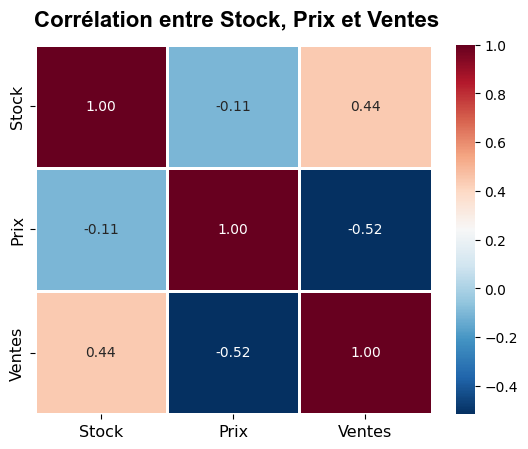

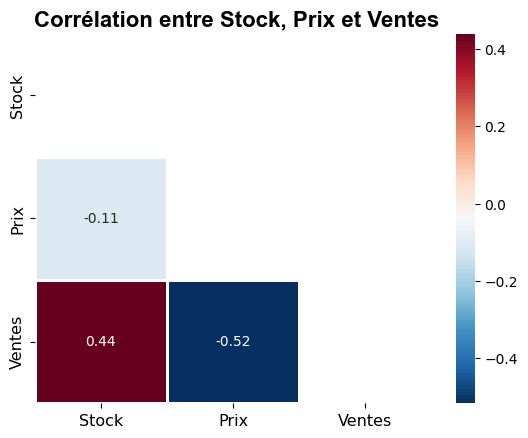

In [156]:
############################
# Analyse des corrélations #
############################

#Création d'une heatmap de corrélation avec les variables stock, sales et price
corr = df_merge[['stock_quantity', 'price', 'total_sales']].corr()

sns.heatmap(corr, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r',
            xticklabels=['Stock', 'Prix', 'Ventes'],
            yticklabels=['Stock', 'Prix', 'Ventes'], 
            linewidths=2)

plt.title("Corrélation entre Stock, Prix et Ventes", fontname='Arial' , fontweight='bold', pad=14, fontsize=16, x=0.51, ha='center')
plt.tick_params(axis='x', labelsize=11.5)
plt.tick_params(axis='y', labelsize=11.5)

plt.show()
#On peut également créer un mask pour n'afficher qu'une demi heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr,
            mask=mask,
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r',
            xticklabels=['Stock', 'Prix', 'Ventes'],
            yticklabels=['Stock', 'Prix', 'Ventes'], 
            linewidths=2)

plt.title("Corrélation entre Stock, Prix et Ventes", fontname='Arial' , fontweight='bold', fontsize=16, x=0.51, ha='center')
plt.tick_params(axis='x', labelsize=11.5)
plt.tick_params(axis='y', labelsize=11.5)

plt.show()

In [157]:
#Que peut-on conclure des corrélations ?
print("-0.52 entre Prix et Ventes : Correlation négative : quand le prix monte, les ventes descendent assez nettement.")
print("0.44 entre Stock et Ventes : Corrélation positive modérée : plus de ventes sur les produits les plus stockés (ou choix de stocker plus les best-sellers)")
print("-0.11 entre Stock et Prix : Corrélation proche de 0 : le prix n'influence pas vraiment la stratégie de volume de stock, ou inversement.")

-0.52 entre Prix et Ventes : Correlation négative : quand le prix monte, les ventes descendent assez nettement.
0.44 entre Stock et Ventes : Corrélation positive modérée : plus de ventes sur les produits les plus stockés (ou choix de stocker plus les best-sellers)
-0.11 entre Stock et Prix : Corrélation proche de 0 : le prix n'influence pas vraiment la stratégie de volume de stock, ou inversement.


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [158]:
# Mettre le dataset df_merge sur un fichier Excel
# Cette étape peut être utile pour partager le résultat du dataset obtenu avec les équipes. 

# df_merge.to_excel('df_merge.xlsx', index=False) 
